<a href="https://colab.research.google.com/github/aarishaarif/Supervised-Machine-Learning-Models/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [93]:
data = pd.read_csv('/content/DailyDelhiClimateTest.csv')
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [94]:
data.shape

(114, 5)

In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


In [96]:
data.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [97]:
data.duplicated().sum()

np.int64(0)

In [98]:
data.describe()

,meantemp,humidity,wind_speed,meanpressure
count,114.000000,114.000000,114.000000,114.000000
mean,21.713079,56.258362,8.143924,1004.035090
std,6.360072,19.068083,3.588049,89.474692
min,11.000000,17.750000,1.387500,59.000000
25%,16.437198,39.625000,5.563542,1007.437500
50%,19.875000,57.750000,8.069444,1012.739316
75%,27.705357,71.902778,10.068750,1016.739583
max,34.500000,95.833333,19.314286,1022.809524


In [99]:
data.drop(columns=['date'],inplace=True)

In [100]:
data.columns

Index(['meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='object')

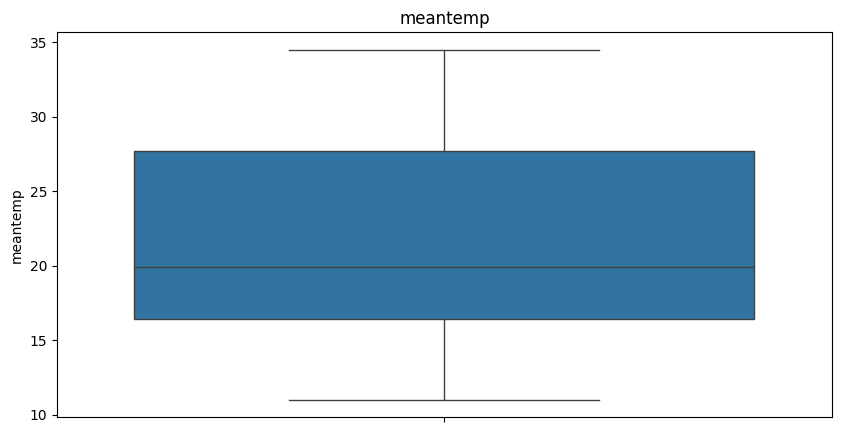

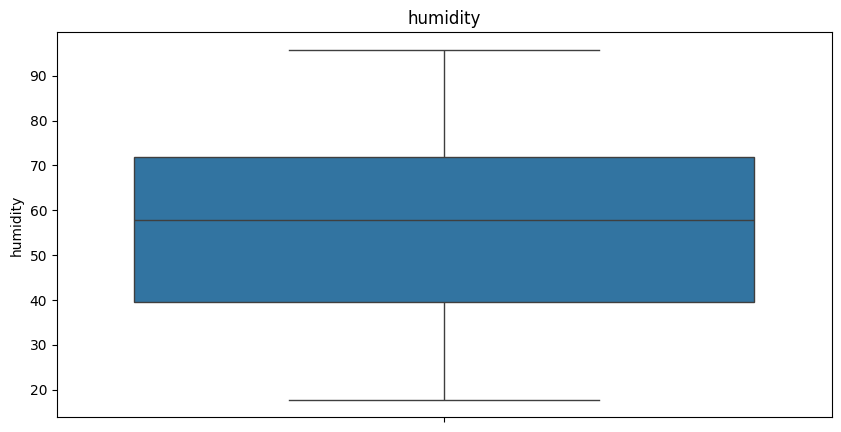

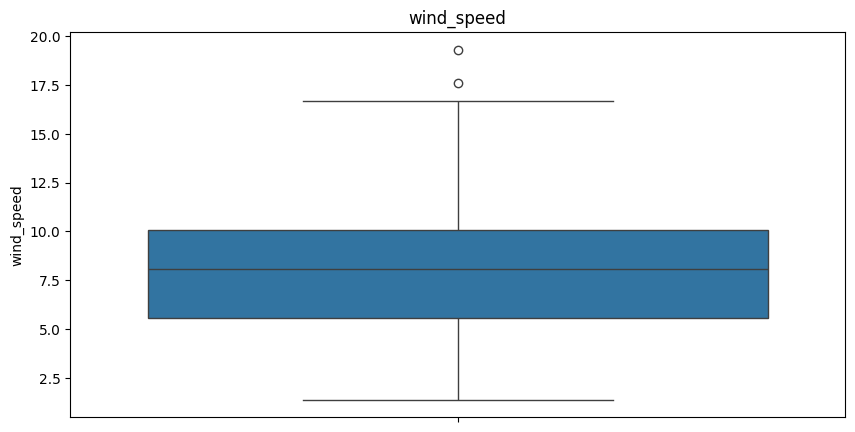

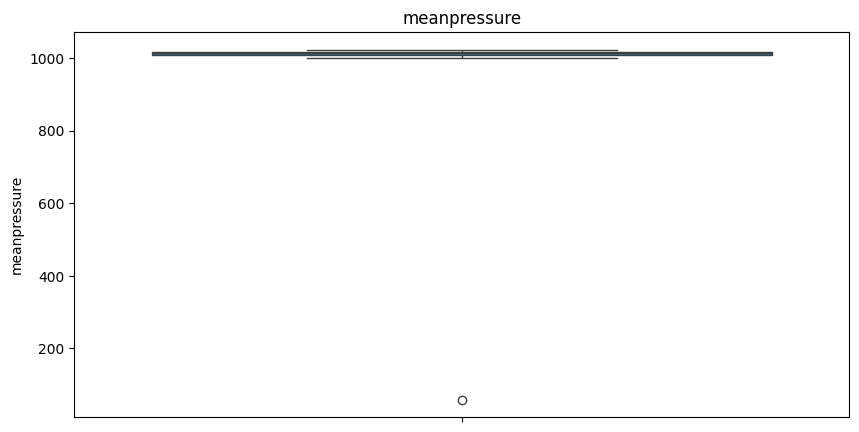

In [101]:
num_col=data.select_dtypes(include=np.number).columns
for col in num_col:
  plt.figure(figsize=(10,5))
  sns.boxplot(data[col])
  plt.title(col)
  plt.show()

In [102]:
outlier_summary = {}

for col in num_col:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'meantemp': 0, 'humidity': 0, 'wind_speed': 2, 'meanpressure': 1}


In [103]:
outlier_col = ['wind_speed','meanpressure']
for col in outlier_col:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  data[col] = data[col].clip(lower,upper)

In [104]:
outlier_summary = {}

for col in num_col:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'meantemp': 0, 'humidity': 0, 'wind_speed': 0, 'meanpressure': 0}


In [105]:
X = data.drop(columns=['meantemp'],axis =1 )
y = data['meantemp']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [106]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [107]:
dt = DecisionTreeRegressor(
    max_depth=2,
    random_state=42,
    min_samples_leaf=5,
    min_samples_split=10

)


dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)

In [108]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))

R2 Score: 0.7300115029724905
MAE: 2.633887170968198


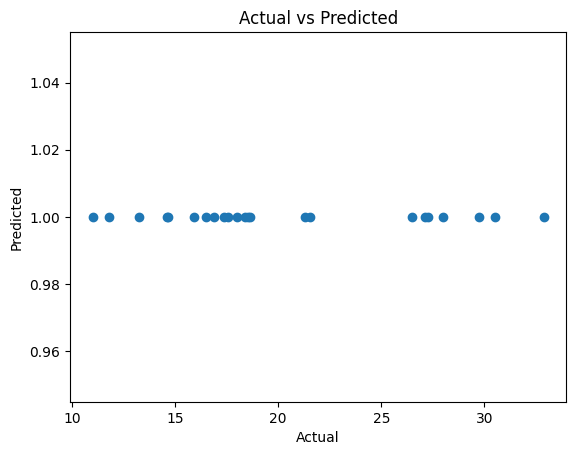

In [109]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [110]:
print("Train Score (Decision Tree):", dt.score(X_train, y_train))
print("Test Score (Decision Tree):", dt.score(X_test, y_test))

Train Score (Decision Tree): 0.8527156521946245
Test Score (Decision Tree): 0.7300115029724905


In [111]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': range(1, 15)
}


grid_search_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42, min_samples_leaf=5, min_samples_split=10),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

print(f"Best hyperparameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best cross-validation R2 score: {grid_search_dt.best_score_:.4f}")


best_dt_model = grid_search_dt.best_estimator_

y_pred_best_dt = best_dt_model.predict(X_test)
print(f"Test R2 score with best Decision Tree: {r2_score(y_test, y_pred_best_dt):.4f}")
print(f"Test MAE with best Decision Tree: {mean_absolute_error(y_test, y_pred_best_dt):.4f}")

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best hyperparameters for Decision Tree: {'max_depth': 4}
Best cross-validation R2 score: 0.7527
Test R2 score with best Decision Tree: 0.8169
Test MAE with best Decision Tree: 2.0129


In [112]:
print("Train Score (Tuned):", best_dt_model.score(X_train, y_train))
print("Test Score (Tuned):", best_dt_model.score(X_test, y_test))

Train Score (Tuned Decision Tree): 0.9099383011898714
Test Score (Tuned Decision Tree): 0.816949653084033


In [113]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_best_dt_again = best_dt_model.predict(X_test)

print("R2 Score (Tuned):", r2_score(y_test, y_pred_best_dt_again))
print("MAE (Tuned):", mean_absolute_error(y_test, y_pred_best_dt_again))

R2 Score (Tuned Decision Tree): 0.816949653084033
MAE (Tuned Decision Tree): 2.0129057271452058
